# Tutorial

- This tutorial demonstrates how to run RETrace2 with the provided test datasets and interpret the results.
- Two test data are provided in `data/`: HCT116 Human Cell Line and MSH2 Mouse

## Prerequisites
- Docker installed
- RETrace2 repository cloned


# HCT116

## Running the Test Data

- The test dataset consists of 6 single cell samples and includes microsatellite data only. 
- Here's the example command to run the analysis:
    - change your path to the GenomeDB directory


```
#!/bin/bash
nextflow run main.nf \
    -profile docker \
    --samplesheet assets/samplesheet_HCT116.csv \
    --genome_base /path/to/GenomeDB \
    --genome hg38 \
    --target_bed resources/targets/hg38/RETrace2.hg38.1nt10-14bp.12000probes.bed \
    --output_prefix 20230110_HCT116 \
    --run_bootstrap
```

### Expected execution output:
```
 N E X T F L O W   ~  version 25.04.6

Launching `main.nf` [suspicious_chandrasekhar] DSL2 - revision: caa8e97182


===========================================
 RETrace2 Pipeline v1.0
===========================================
Samplesheet        : assets/samplesheet_HCT116.csv
Output directory   : results
Reference genome   : hg38
Profile            : docker
Sequencing mode    : Single-end
Threads            : 4
Memory             : 16.GB
Per Sample parameters:
  - Min targets    : 100
  - Min CpGs       : 0
HipSTR parameters  :
  - Path           : HipSTR (from PATH)
  - Min quality    : 0.9
  - Min reads      : 10
  - Max stutter    : 1
Phylogenetic parameters:
  - Distance metric: minComp_EqorNot
  - Outgroup       : Midpoint
  - Color background: true
  - Circular layout: false
Optional analyses  :
  - Bootstrap      : true
  - Methylation    : false
===========================================

executor >  local (99)
[80/dd88b0] process > MAPPING:FASTQC (4)              [100%] 6 of 6 ✔
[57/400047] process > MAPPING:MULTIQC                 [100%] 1 of 1 ✔
[cd/54e0d9] process > MAPPING:TRIM_GALORE (3)         [100%] 6 of 6 ✔
[44/bbd131] process > MAPPING:BWA_MEM (2)             [100%] 6 of 6 ✔
[0d/3202ae] process > STATS:COUNT_TARGETS (6)         [100%] 6 of 6 ✔
[81/6f5b07] process > STATS:COMBINE_STATS             [100%] 1 of 1 ✔
[17/4b3b36] process > HIPSTR:FILTER_BAMS_BY_STATS (6) [100%] 6 of 6 ✔
[b9/c6c44f] process > HIPSTR:HIPSTR_PER_CHROM (chr2)  [100%] 63 of 63 ✔
[23/45938d] process > HIPSTR:MERGE_VCFS               [100%] 1 of 1 ✔
[ea/d7a33c] process > HIPSTR:PARSE_VCF                [100%] 1 of 1 ✔
[dc/5b280d] process > PHYLO:BUILD_TREE                [100%] 1 of 1 ✔
[83/4acc39] process > PHYLO:VIEW_PHYLO (1)            [100%] 1 of 1 ✔
Pipeline completed at: 2025-07-21T21:51:49.844469384Z
Execution status: SUCCESS
Execution duration: 1m 40s

        ===========================================
         RETrace2 Pipeline - COMPLETED SUCCESSFULLY
        ===========================================
        Results are available in: results
        
        Core results:
        - Microsatellite FASTQC: results/mapping/fastqc/
        - Microsatellite BAM files: results/mapping/bam/
        - Microsatellite statistics: results/stats/ms_counts/
        - Summary statistics: results/stats/
        - HipSTR genotyping: results/hipstr/
        - Phylogenetic tree: results/phylo/newick-orginal.txt
        

        Bootstrap results:
        - Support values: results/phylo/bootstrap_stats.txt
        - Bootstrap trees: results/phylo/newwick-bootstrap.txt
            
===========================================
Completed at: 21-Jul-2025 21:51:49
Duration    : 1m 40s
CPU hours   : 0.2
Succeeded   : 99
```


## 2. Results
- The pipeline runs fastqc and multiQC by default. 
- You check sequencing QC stats in `/results/mapping/fastqc/multiqc_report.html`

### Stats Module

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read per sample stats
stats = pd.read_csv('../results/stats/sample_stats.tsv', sep='\t')
stats.head(6)

,sample_id,ms_targets_with_min_reads,cpg_count,pass
0,HCT116_2-1-C4_3-7-G7_Plate2-2G,500,0,True
1,HCT116_2-1-C4_3-7-G7_Plate2-3G,578,0,True
2,HCT116_2-1-F7_3-3-B9_Plate2-4B,453,0,True
3,HCT116_2-1-F7_3-3-B9_Plate2-4E,654,0,True
4,HCT116_2-1-H9_3-4-D8_Plate2-7E,772,0,True
5,HCT116_2-1-H9_3-4-D8_Plate2-9E,686,0,True


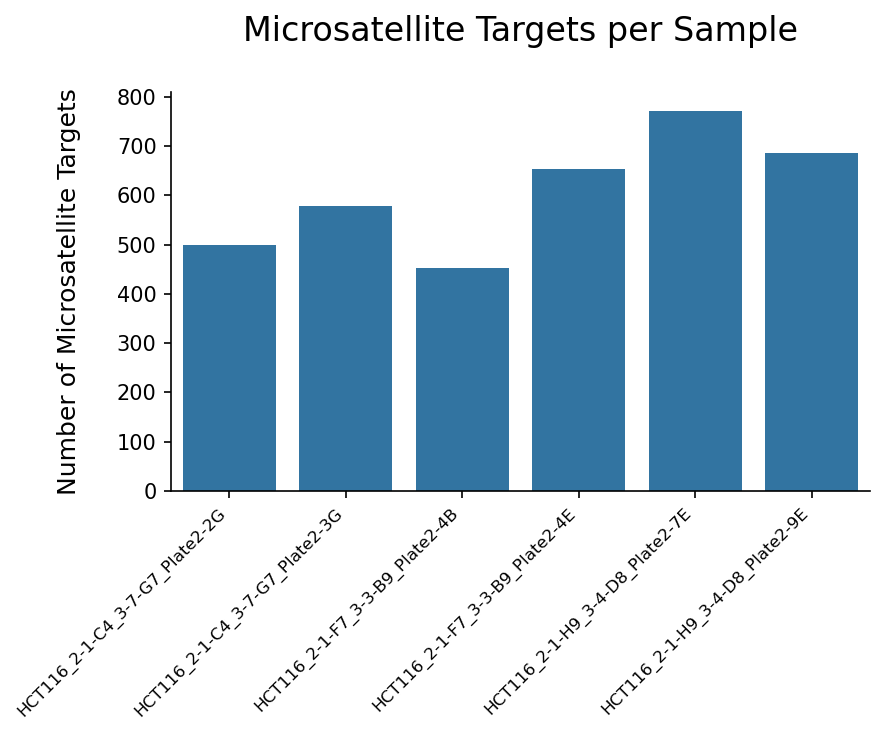

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Plot barplot
sns.barplot(data=stats, x='sample_id', y='ms_targets_with_min_reads', ax=ax)

# Customize axes
ax.set_title('Microsatellite Targets per Sample\n', fontsize=16)
ax.set_ylabel('Number of Microsatellite Targets\n', fontsize=12)
ax.set_xlabel('')

# Get current tick positions to lock them
xticks = ax.get_xticks()
ax.set_xticks(xticks)  # Explicitly set ticks to avoid warning

# Apply formatting to tick labels
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [3]:
# Read summary stats
with open("../results/stats/summary_stats.txt", "r") as file:
    print(file.read())

Filter Parameters:
Minimum reads per target: 10
Minimum targets per sample: 100
Minimum CpGs per sample: 0

Sample Counts:
Total samples: 6
Passing samples: 6
Failed samples: 0

All Samples Statistics:
Mean microsatellite targets (with min reads): 607.17
Median microsatellite targets (with min reads): 616.00
Filtered Samples Statistics:
Mean microsatellite targets (with min reads): 607.17
Median microsatellite targets (with min reads): 616.00



### Phylo Tree Module
- If --run_bootstrap is specified (optional), the pipeline will run the bootstrap analysis.
- This could take a long time to run if sample size is large. 
- You can set the number of bootstrap iterations with --bootstrap_iterations. (Default: 100)
- The red color numbers in the tree are the bootstrap support values for each node.

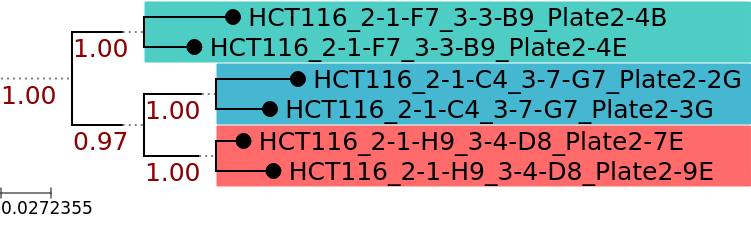

In [4]:
from IPython.display import Image
display(Image("../results/phylo/20230110_HCT116.viewPhylo.png"))

- The result showed cells from the same clones (grouped by color) are clustered together, consistent with the ground truth. 
- We build the cell culture tree model starting from a single cell and therefore has the ground truth of their clonal relationships.
- See full data set in our RETrace2 paper.

# MSH2 Mouse

## 1. Running the Test Data

- The test dataset consists of 3 single cell samples and includes both microsatellite and methylation data. 
- Here's the command to run the complete analysis:
    - change your path to the `genome_base` and `celltype_ref_dir` directory


```
#!/bin/bash
nextflow run main.nf \
    -profile docker \
    --samplesheet assets/samplesheet_msh2.csv \
    --genome_base /path/to/GenomeDB \
    --genome mm39 \
    --target_bed resources/targets/mm39/RETrace2.mm39.1nt10-30bp.92460targets169818probes.bed \
    --output_dir results_msh2 \
    --output_prefix 20250427_msh2_female \
    --run_bootstrap \
    --run_methylation \
    --celltype_ref_dir /path/to/RETrace2_methylation_ref \
    --celltype_ref_pattern "*tsv.gz"
```

### Expected execution output:
```
 N E X T F L O W   ~  version 25.04.6

Launching `main.nf` [distraught_kare] DSL2 - revision: c8018b6413


===========================================
 RETrace2 Pipeline v1.0
===========================================
Samplesheet        : assets/samplesheet_msh2.csv
Output directory   : results_msh2
Reference genome   : mm39
Profile            : docker
Sequencing mode    : Single-end
Threads            : 4
Memory             : 16.GB
Per Sample parameters:
  - Min targets    : 100
  - Min CpGs       : 0
HipSTR parameters  :
  - Path           : HipSTR (from PATH)
  - Min quality    : 0.9
  - Min reads      : 10
  - Max stutter    : 1
Phylogenetic parameters:
  - Distance metric: minComp_EqorNot
  - Outgroup       : Midpoint
  - Color background: true
  - Circular layout: false
Optional analyses  :
  - Bootstrap      : true
  - Methylation    : true
===========================================

executor >  local (75)
[fa/3fa72e] process > MAPPING:FASTQC (2)                 [100%] 3 of 3 ✔
[80/e212c2] process > MAPPING:MULTIQC                    [100%] 1 of 1 ✔
[95/820534] process > MAPPING:TRIM_GALORE (2)            [100%] 3 of 3 ✔
[d4/3f75e0] process > MAPPING:BWA_MEM (2)                [100%] 3 of 3 ✔
[16/0447eb] process > METHYLATION:METH_FASTQC (2)        [100%] 3 of 3 ✔
[75/e5420a] process > METHYLATION:METH_MULTIQC           [100%] 1 of 1 ✔
[ff/8dff15] process > METHYLATION:METH_TRIM_GALORE (3)   [100%] 3 of 3 ✔
[86/a765c8] process > METHYLATION:METHYLPY (3)           [100%] 3 of 3 ✔
[c4/26dc16] process > STATS:COUNT_TARGETS (3)            [100%] 3 of 3 ✔
[25/824045] process > STATS:COMBINE_STATS                [100%] 1 of 1 ✔
[1f/44e778] process > HIPSTR:FILTER_BAMS_BY_STATS (3)    [100%] 3 of 3 ✔
[3c/8c4f4a] process > HIPSTR:HIPSTR_PER_CHROM (chr18)    [100%] 42 of 42 ✔
[44/790ec0] process > HIPSTR:MERGE_VCFS                  [100%] 1 of 1 ✔
[ee/009639] process > HIPSTR:PARSE_VCF                   [100%] 1 of 1 ✔
[d8/0fb369] process > PHYLO:BUILD_TREE                   [100%] 1 of 1 ✔
[95/6fe3a0] process > PHYLO:VIEW_PHYLO (1)               [100%] 1 of 1 ✔
[fe/654f98] process > INFER_CELLTYPE:CALCULATE_PD_MATRIX [100%] 1 of 1 ✔
[2c/9ef2ae] process > INFER_CELLTYPE:ASSIGN_CELLTYPE     [100%] 1 of 1 ✔
Pipeline completed at: 2025-07-21T21:30:52.058628541Z
Execution status: SUCCESS
Execution duration: 8m 41s

        ===========================================
         RETrace2 Pipeline - COMPLETED SUCCESSFULLY
        ===========================================
        Results are available in: results_msh2
        
        Core results:
        - Microsatellite FASTQC: results_msh2/mapping/fastqc/
        - Microsatellite BAM files: results_msh2/mapping/bam/
        - Microsatellite statistics: results_msh2/stats/ms_counts/
        - Summary statistics: results_msh2/stats/
        - HipSTR genotyping: results_msh2/hipstr/
        - Phylogenetic tree: results_msh2/phylo/newick-orginal.txt
        

        Bootstrap results:
        - Support values: results_msh2/phylo/bootstrap_stats.txt
        - Bootstrap trees: results_msh2/phylo/newwick-bootstrap.txt
            

        Methylation results:
        - Methylation FASTQC: results_msh2/methylation/fastqc/
        - Methylation allc files: results_msh2/methylation/methylpy/
        - Combined statistics: results_msh2/stats/ (includes both MS and CpG data)
            

        Cell type inference results:
        - Pairwise dissimilarity matrix: results_msh2/infer_celltype/pd_matrix/
        - Cell type assignments: results_msh2/infer_celltype/assignments/
        - Z-score matrix: results_msh2/infer_celltype/assignments/
        - Cell type plots: results_msh2/infer_celltype/assignments/
                
===========================================
Completed at: 21-Jul-2025 21:30:52
Duration    : 8m 41s
CPU hours   : 1.1
Succeeded   : 75
```


## 2. Results


### Stats Module

In [5]:
# Read per sample stats
stats_msh2 = pd.read_csv('../results_msh2/stats/sample_stats.tsv', sep='\t')
stats_msh2.head()

,sample_id,ms_targets_with_min_reads,cpg_count,pass
0,Brain-PostCortex-NeuNpos-4F,11028,3647,True
1,Brain-PostCortex-NeuNpos-5F,10818,3675,True
2,Kidney-Cortex-1-7C,10746,5821,True


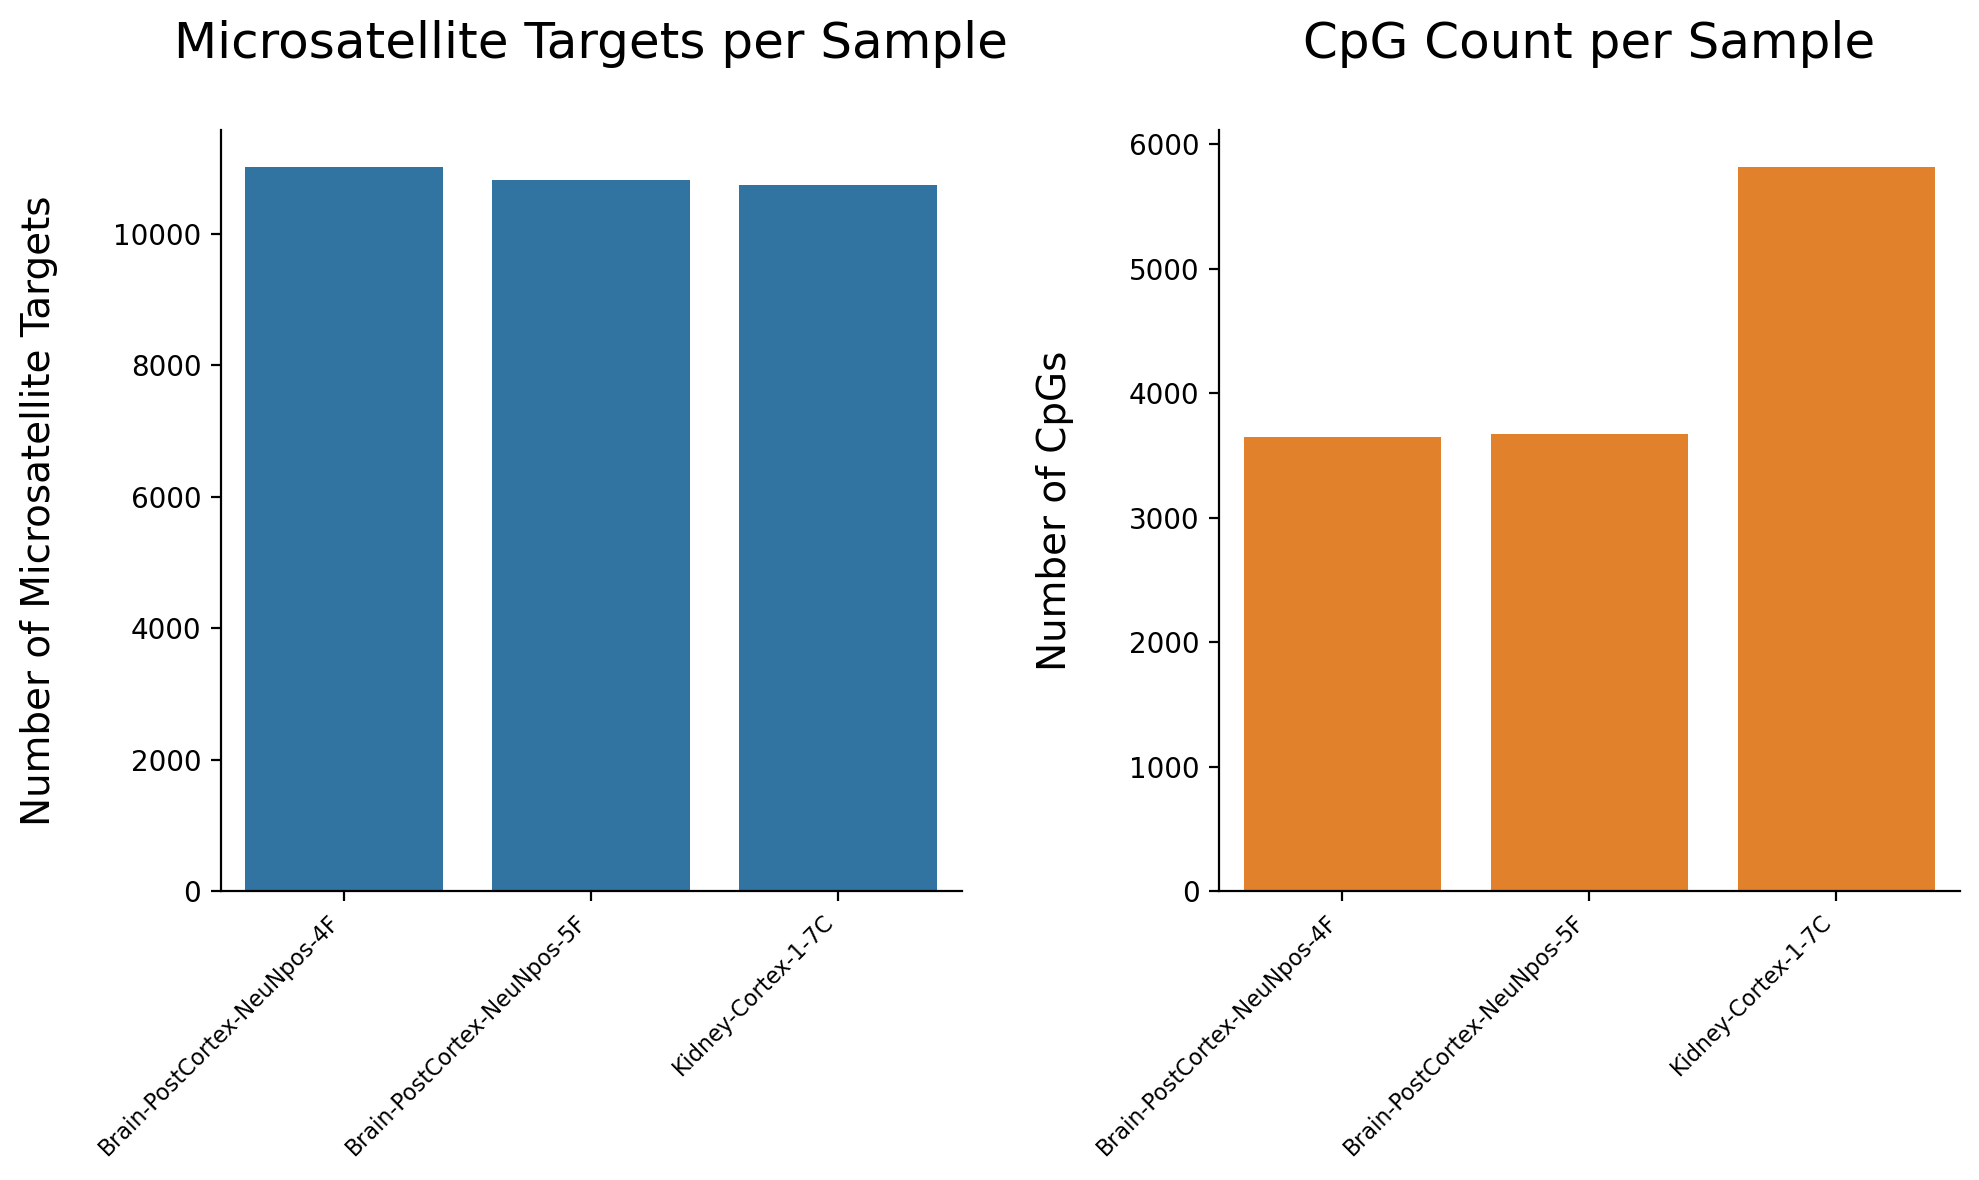

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6), dpi=200)

sns.barplot(data=stats_msh2, x='sample_id', y='ms_targets_with_min_reads', ax=ax1)
sns.barplot(data=stats_msh2, x='sample_id', y='cpg_count', color='tab:orange', ax=ax2)

ax1.set_title('Microsatellite Targets per Sample\n', fontsize=18)
ax1.set_ylabel('Number of Microsatellite Targets\n', fontsize=14)
ax1.set_xlabel('')

ax2.set_title('CpG Count per Sample\n', fontsize=18)
ax2.set_ylabel('\nNumber of CpGs\n', fontsize=14)
ax2.set_xlabel('')

for ax in [ax1, ax2]:
    xticks = ax.get_xticks()
    ax.set_xticks(xticks) 
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [7]:
# Read summary stats
with open("../results_msh2/stats/summary_stats.txt", "r") as file:
    summary_stats = file.read()

print(summary_stats)


Filter Parameters:
Minimum reads per target: 10
Minimum targets per sample: 100
Minimum CpGs per sample: 0

Sample Counts:
Total samples: 3
Passing samples: 3
Failed samples: 0

All Samples Statistics:
Mean microsatellite targets (with min reads): 10864.00
Median microsatellite targets (with min reads): 10818.00
Mean CpG count: 4381.00
Median CpG count: 3675.00
Mean CpG methylation rate: 0.4097
Median CpG methylation rate: 0.3693

Filtered Samples Statistics:
Mean microsatellite targets (with min reads): 10864.00
Median microsatellite targets (with min reads): 10818.00
Mean CpG count: 4381.00
Median CpG count: 3675.00
Mean CpG methylation rate: 0.4097
Median CpG methylation rate: 0.3693



In [8]:
# Read summary stats
with open("../results_msh2/stats/summary_stats.txt", "r") as file:
    print(file.read())

Filter Parameters:
Minimum reads per target: 10
Minimum targets per sample: 100
Minimum CpGs per sample: 0

Sample Counts:
Total samples: 3
Passing samples: 3
Failed samples: 0

All Samples Statistics:
Mean microsatellite targets (with min reads): 10864.00
Median microsatellite targets (with min reads): 10818.00
Mean CpG count: 4381.00
Median CpG count: 3675.00
Mean CpG methylation rate: 0.4097
Median CpG methylation rate: 0.3693

Filtered Samples Statistics:
Mean microsatellite targets (with min reads): 10864.00
Median microsatellite targets (with min reads): 10818.00
Mean CpG count: 4381.00
Median CpG count: 3675.00
Mean CpG methylation rate: 0.4097
Median CpG methylation rate: 0.3693



### Phylo Tree Module
- If --run_bootstrap is specified (optional), the pipeline will run the bootstrap analysis.
- This could take a long time to run if sample size is large. 
- You can set the number of bootstrap iterations with --bootstrap_iterations. (Default: 100)
- The red color numbers in the tree are the bootstrap support values for each node.

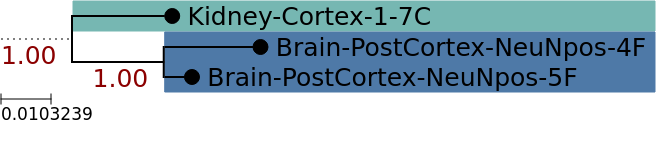

In [9]:
from IPython.display import Image
display(Image("../results_msh2/phylo/20250427_msh2_female.viewPhylo.png"))

### Methylation - Infer Cell Type Module
- If --run_methylation is specified, the pipeline will run the methylation analysis. 
- This pipeline is optional, run only if you have dual-omic data (microsatellite and methylation).

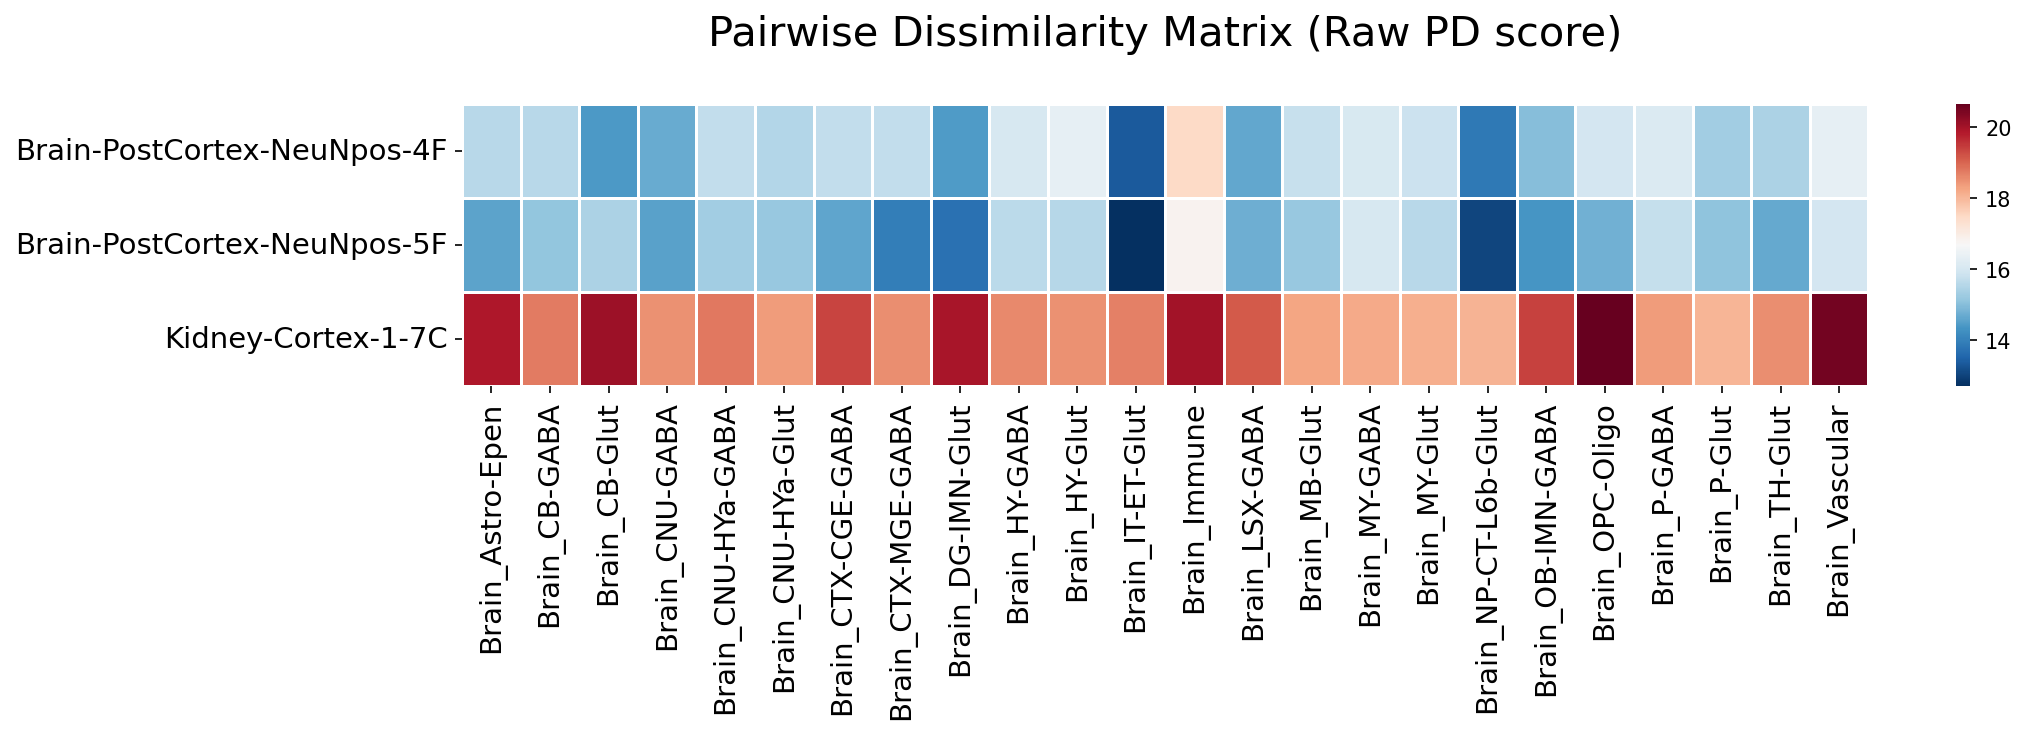

In [10]:
pd_matrix_raw = pd.read_csv('../results_msh2/infer_celltype/pd_matrix/pairwise_dissimilarity_matrix.csv', index_col=0)

plt.figure(figsize=(15, 5), dpi=150)
sns.heatmap(pd_matrix_raw, cmap='RdBu_r', linewidths=0.5, yticklabels=True)
plt.title(f'Pairwise Dissimilarity Matrix (Raw PD score)\n', fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()

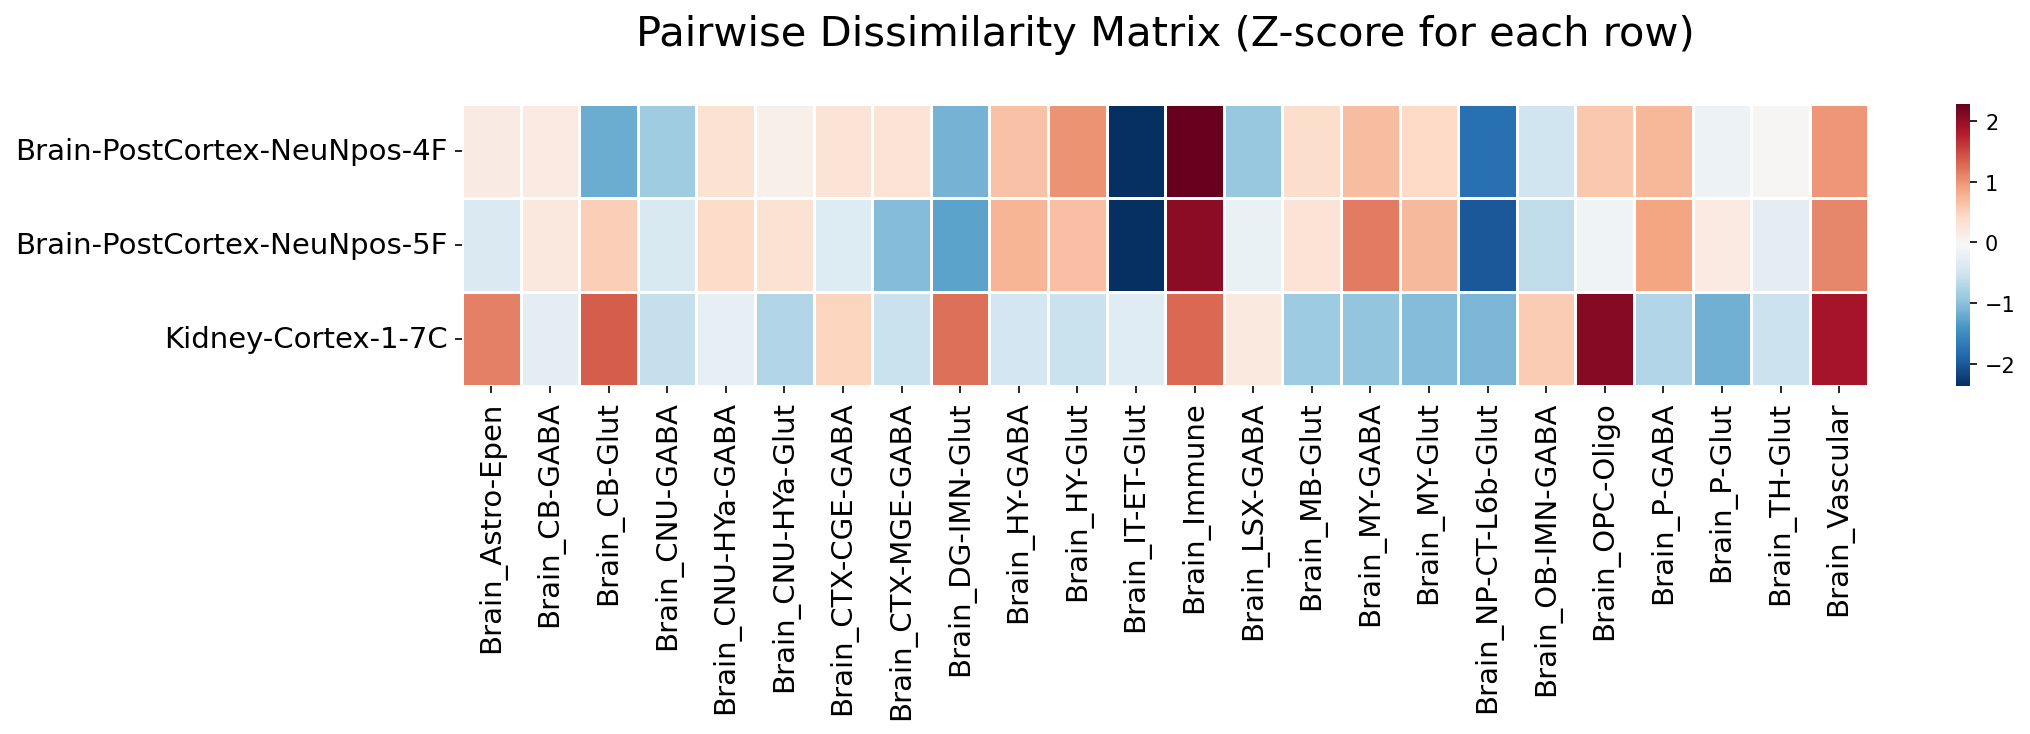

In [11]:
pd_matrix_zscore = pd.read_csv('../results_msh2/infer_celltype/assignments/zscore_matrix.csv', index_col=0)

plt.figure(figsize=(15, 5), dpi=150)
sns.heatmap(pd_matrix_zscore, cmap='RdBu_r', linewidths=0.5, yticklabels=True)
plt.title(f'Pairwise Dissimilarity Matrix (Z-score for each row)\n', fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14, rotation=0)
plt.tight_layout()

In [12]:
# View cell type assignments
celltype_assignments = pd.read_csv('../results_msh2/infer_celltype/assignments/celltype_assignments.tsv', sep='\t')
celltype_assignments.head()

,Sample_ID,Best_Match,Min_Zscore,Second_Best_Match,Second_Best_Zscore,Passes_Threshold,Assignment
0,Brain-PostCortex-NeuNpos-4F,Brain_IT-ET-Glut,-2.366055,Brain_NP-CT-L6b-Glut,-1.802907,True,Brain_IT-ET-Glut
1,Brain-PostCortex-NeuNpos-5F,Brain_IT-ET-Glut,-2.355784,Brain_NP-CT-L6b-Glut,-2.013971,True,Brain_IT-ET-Glut
2,Kidney-Cortex-1-7C,Brain_P-Glut,-1.149076,Brain_NP-CT-L6b-Glut,-1.104380,False,Unassigned


- Pariwise dissimilarity matrix is calculated by running */RETrace2/modules/infer_celltype/calculate_pd_matrix_batched.py*
- The lower the PD score (blue), the more similar the two cells are.
- Test data was run using only brain cell type references as example, so you can see the Kideny sample shows higher PD score (less similar) when mapping to brain references.
- When transformed to z-score, we did not see Kideny sample showing a low enough z-score to pass the threshold (default -1.2), hence cell type was not assigned. This demonstrates z-score as a useful metric to assess confidence in cell type assignment.
- See [notebooks/Fig4_Methylation_Infer_CellType.ipynb](Fig4_Methylation_Infer_CellType.ipynb) for details on how the methods works and how z-score thereshold was determined using postive controls.